# MZM MLP PINN — Hyperparameter Tuning

## Overview
This notebook performs hyperparameter tuning for the Multi-Layer Perceptron Physics-Informed Neural Network (MLP-PINN) model for Mach-Zehnder Modulator (MZM) modeling.

### Hyperparameters Tuned
| Parameter | Description |
|---|---|
| `lambda_bw_mon` | Weight for BW monotonicity constraint ($\partial BW / \partial L \le 0$) |
| `lambda_IL_mon` | Weight for IL monotonicity constraint ($\partial IL / \partial L \ge 0$) |
| `lambda_vpiL` | Weight for $V_\pi \cdot L$ conservation constraint |
| `lambda_smooth` | Weight for smoothness (second derivative) constraint |

We use **Optuna** for efficient Bayesian-style hyperparameter search with pruning of unpromising trials.

In [ ]:
# ==============================
# Install JAX, Flax, Optax, Optuna
# ==============================wanan
# !pip install "jax[cuda]" flax optax optuna
# For CPU-only: !pip install jax flax optax optuna

In [ ]:
# ==============================
# Import Required Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import re
import json
import itertools
from copy import deepcopy
import functools
import pickle

import jax
import jax.numpy as jnp
from jax import random
import flax.linen as nn
import optax

import optuna
from optuna.trial import TrialState

# Reproducibility
random_state = 123
np.random.seed(random_state)
rng_key = random.PRNGKey(random_state)

/home/salastro/Documents/Research/MZM/code/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Definitions

In [ ]:
class MLP5(nn.Module):
    input_dim: int = 8
    output_dim: int = 3
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, x, training: bool = False):
        residual = x

        ki = nn.initializers.he_uniform()
        bi = nn.initializers.zeros_init()

        x = nn.Dense(1350, kernel_init=ki, bias_init=bi)(x)
        x = nn.BatchNorm(use_running_average=not training)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not training)(x)

        x = nn.Dense(200, kernel_init=ki, bias_init=bi)(x)
        x = nn.BatchNorm(use_running_average=not training)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not training)(x)

        x = nn.Dense(300, kernel_init=ki, bias_init=bi)(x)
        x = nn.BatchNorm(use_running_average=not training)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not training)(x)

        x = nn.Dense(350, kernel_init=ki, bias_init=bi)(x)
        x = nn.BatchNorm(use_running_average=not training)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not training)(x)

        x = nn.Dense(300, kernel_init=ki, bias_init=bi)(x)
        x = nn.BatchNorm(use_running_average=not training)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not training)(x)

        x = nn.Dense(200, kernel_init=ki, bias_init=bi)(x)
        x = nn.BatchNorm(use_running_average=not training)(x)
        x = nn.relu(x)
        x = nn.Dropout(rate=self.dropout_rate, deterministic=not training)(x)

        # Residual connection with padding/truncation
        if residual.shape[-1] < x.shape[-1]:
            pad_width = x.shape[-1] - residual.shape[-1]
            residual = jnp.pad(residual, ((0, 0), (0, pad_width)))
        elif residual.shape[-1] > x.shape[-1]:
            residual = residual[:, :x.shape[-1]]

        x = x + residual

        x = nn.Dense(self.output_dim, kernel_init=ki, bias_init=bi)(x)
        return x

## Data Loading & Preprocessing

In [3]:
# ==============================
# Load and Preprocess Data
# ==============================
# from google.colab import drive
# drive.mount('/content/drive')
# file_path = "/content/drive/MyDrive/MZM Data/Sim_generated_dataset.txt"
file_path = "Sim_generated_dataset.txt"

In [ ]:
with open(file_path) as f:
    cleaned = [re.sub(r'[\[\]]', '', line.strip()) for line in f]

df = pd.read_csv(StringIO("\n".join(cleaned)), header=None)
df.columns = [
    "PN_offset", "Bias_V", "Core_width", "P+_width", "N+_width",
    "P_width", "N_width", "Phase_length", "BW_3dB", "IL", "V_pi"
]

# Data cleaning: remove rows with extreme V_pi (>500, <0)
df_cleaned = df[(df['V_pi'] < 500) & (df['V_pi'] > 0)].copy()
print(f"Dataset size after cleaning: {len(df_cleaned)} samples")

# Split features / targets
feature_cols = df_cleaned.columns[:8]
target_cols = df_cleaned.columns[8:]

x = df_cleaned[feature_cols].values
y = df_cleaned[target_cols].values

# Train / test split
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x, y, test_size=0.1, random_state=random_state
)

# ==============================
# Scaling (fit on TRAIN only)
# ==============================
scaler_x = StandardScaler()
scaler_y1 = StandardScaler()  # BW_3dB
scaler_y2 = StandardScaler()  # IL
scaler_y3 = StandardScaler()  # V_pi

x_train_scaled = scaler_x.fit_transform(x_train_raw)
y_train_scaled = np.hstack([
    scaler_y1.fit_transform(y_train_raw[:, 0:1]),
    scaler_y2.fit_transform(y_train_raw[:, 1:2]),
    scaler_y3.fit_transform(y_train_raw[:, 2:3]),
])

x_test_scaled = scaler_x.transform(x_test_raw)
y_test_scaled = np.hstack([
    scaler_y1.transform(y_test_raw[:, 0:1]),
    scaler_y2.transform(y_test_raw[:, 1:2]),
    scaler_y3.transform(y_test_raw[:, 2:3]),
])

# Convert to JAX arrays
x_train_t = jnp.array(x_train_scaled, dtype=jnp.float32)
y_train_t = jnp.array(y_train_scaled, dtype=jnp.float32)
x_test_t  = jnp.array(x_test_scaled, dtype=jnp.float32)
y_test_t  = jnp.array(y_test_scaled, dtype=jnp.float32)

print(f"Train: {x_train_t.shape[0]} | Test: {x_test_t.shape[0]}")
df_cleaned.describe()

Dataset size after cleaning: 9614 samples
Train: 8652 | Test: 962


,PN_offset,Bias_V,Core_width,P+_width,N+_width,P_width,N_width,Phase_length,BW_3dB,IL,V_pi
count,9.614000e+03,9614.000000,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9.614000e+03,9614.000000,9614.000000,9614.000000,9614.000000
mean,-4.106982e-09,-5.965076,4.774007e-07,2.584718e-07,2.618829e-07,7.853203e-07,7.904345e-07,0.002285,46.011836,1.577726,33.900601
std,1.272187e-07,2.251585,2.488443e-08,1.315607e-07,1.370419e-07,1.293550e-07,1.313482e-07,0.001030,13.757979,0.896971,31.995194
min,-2.150000e-07,-10.000000,4.050720e-07,4.509540e-08,4.500550e-08,4.510390e-07,4.501570e-07,0.000500,2.256410,0.166187,3.564810
25%,-1.064180e-07,-7.874185,4.613922e-07,1.472730e-07,1.420500e-07,6.774380e-07,6.796328e-07,0.001415,34.923077,0.881409,14.321325
50%,0.000000e+00,-5.819890,4.754365e-07,2.522630e-07,2.602395e-07,7.865730e-07,7.942275e-07,0.002229,44.974359,1.394790,23.757300
75%,9.655928e-08,-4.041150,4.891833e-07,3.689188e-07,3.806483e-07,8.958177e-07,9.036680e-07,0.003167,54.800000,2.162227,41.027525
max,2.150000e-07,-2.250820,6.000000e-07,4.998190e-07,5.000000e-07,1.098400e-06,1.099670e-06,0.005971,74.000000,5.255890,394.839000


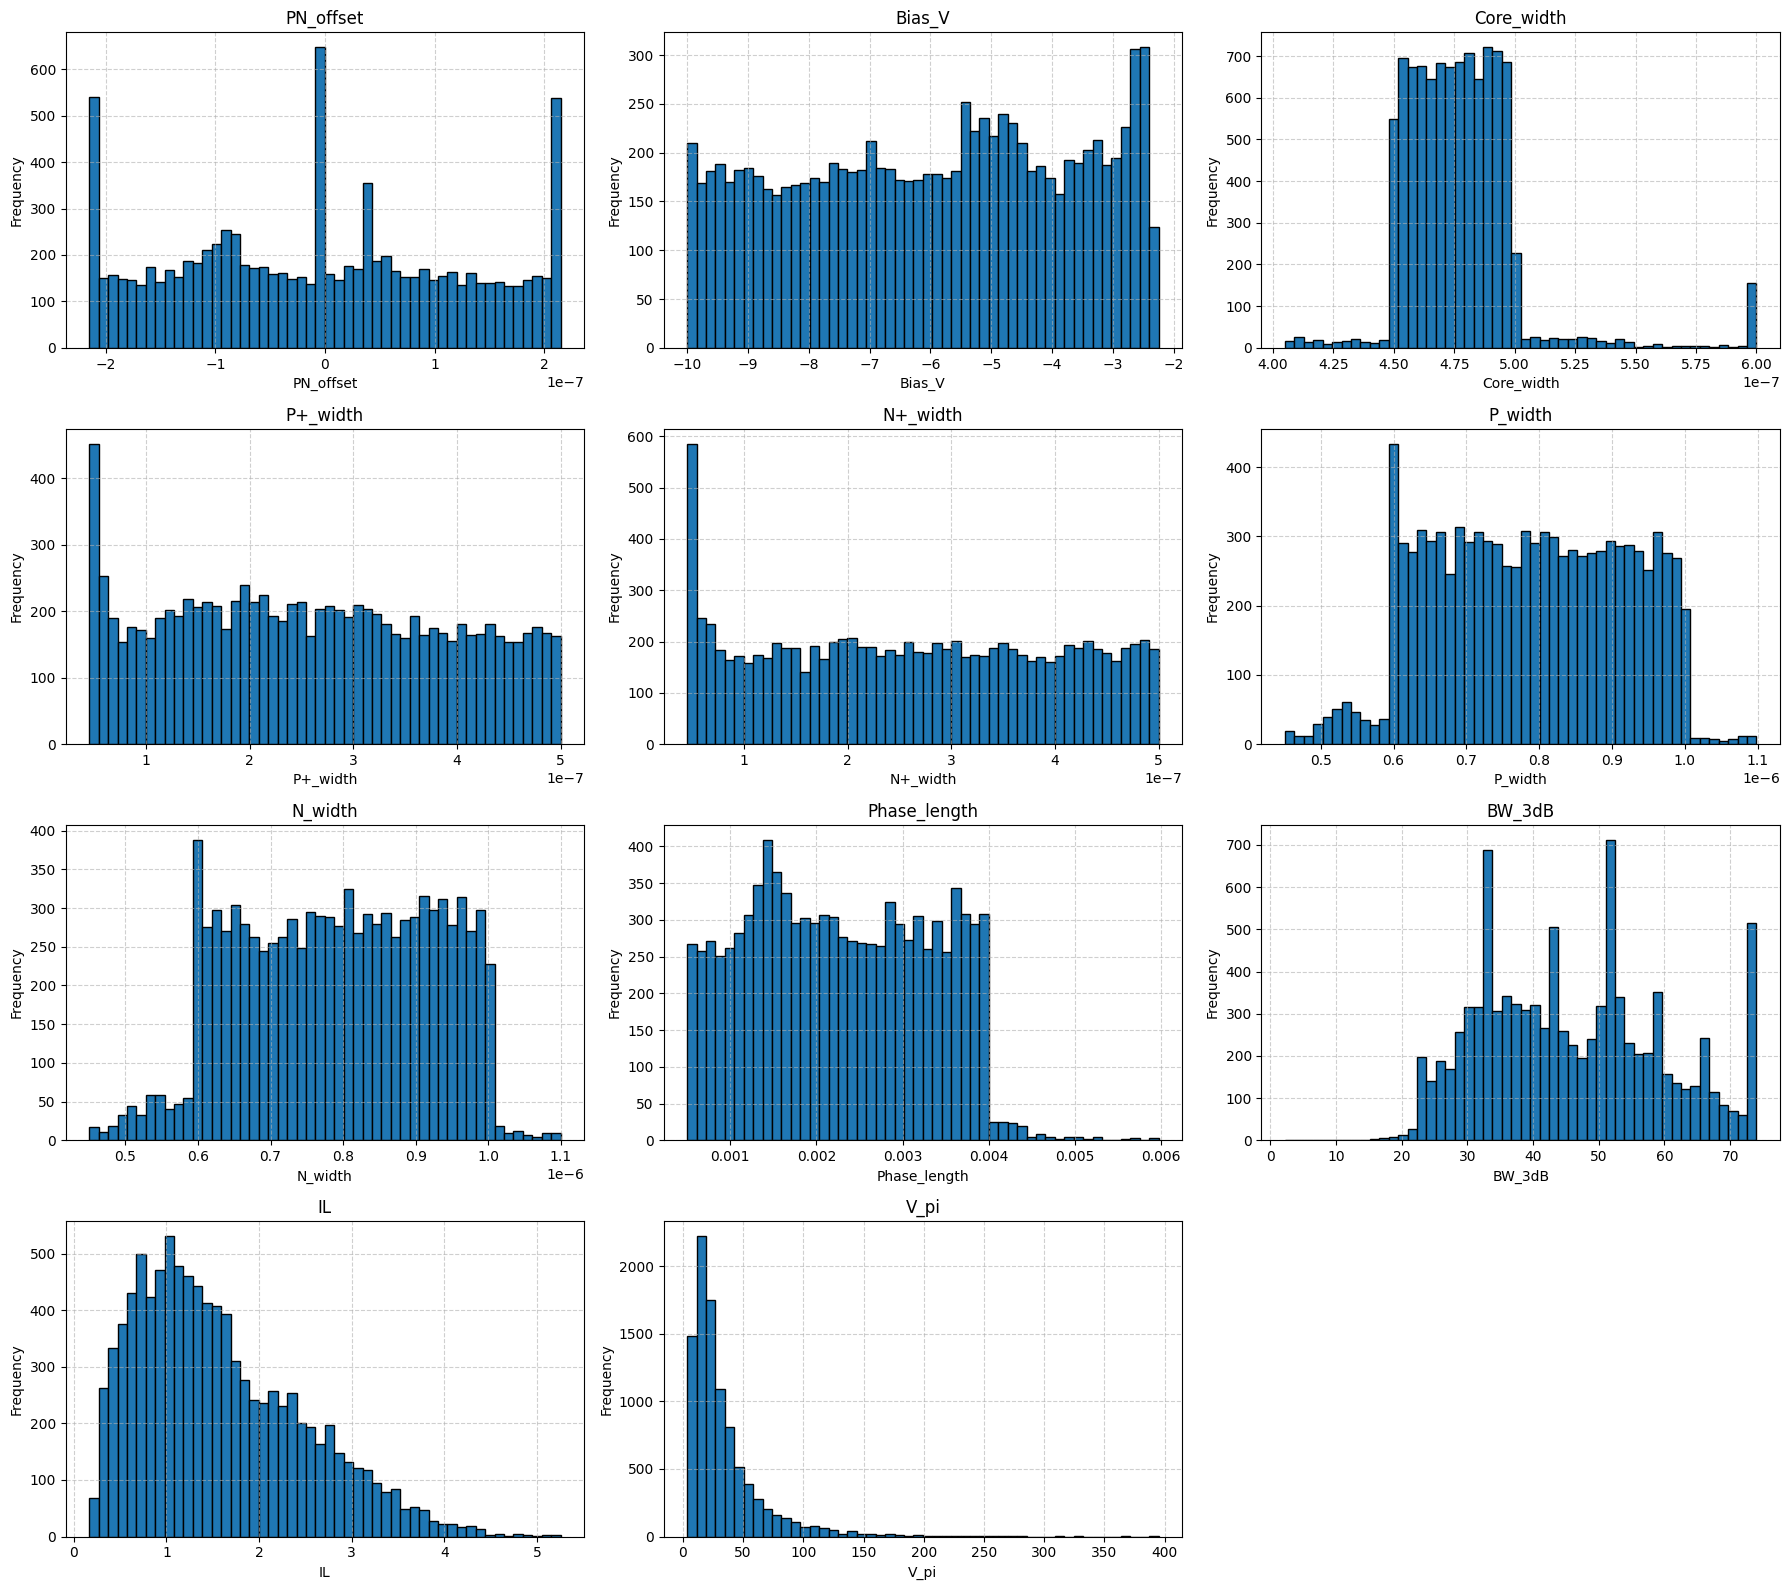

In [5]:
# Combine all columns
all_cols = list(feature_cols) + list(target_cols)
n_cols = len(all_cols)

# Define grid size
n_grid_cols = 3
n_grid_rows = 4

fig, axes = plt.subplots(
    nrows=n_grid_rows,
    ncols=n_grid_cols,
    figsize=(6 * n_grid_cols, 4 * n_grid_rows)
)

axes = axes.flatten()

for i, col in enumerate(all_cols):
    axes[i].hist(df_cleaned[col], bins=50, edgecolor='black')
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

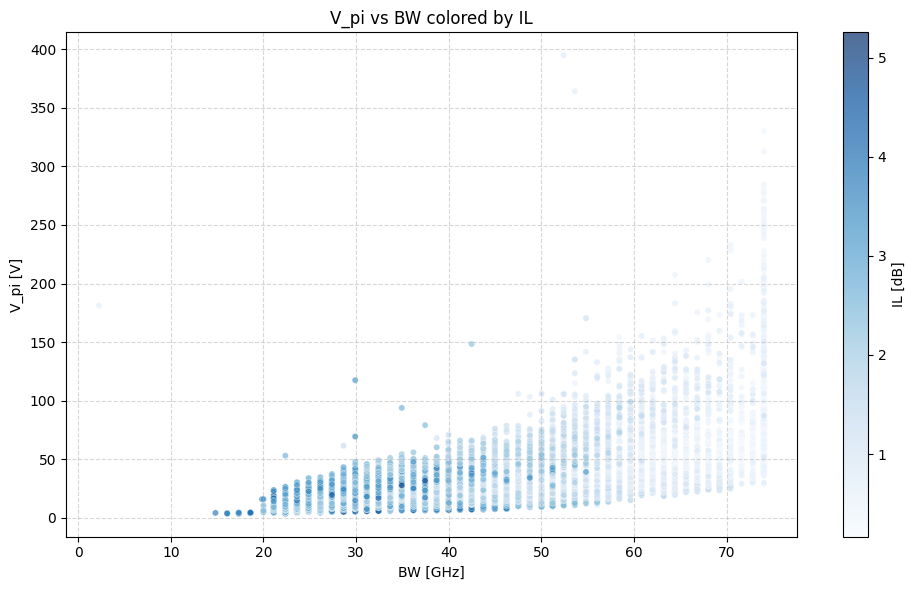

In [6]:
x = df_cleaned['BW_3dB']
y = df_cleaned['V_pi']
c = df_cleaned['IL']

plt.figure(figsize=(10,6))
sc = plt.scatter(x, y, c=c, cmap='Blues', alpha=0.7, s=20, edgecolors='w', linewidth=0.3)

plt.xlabel('BW [GHz]')
plt.ylabel('V_pi [V]')
plt.title('V_pi vs BW colored by IL')

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('IL [dB]')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

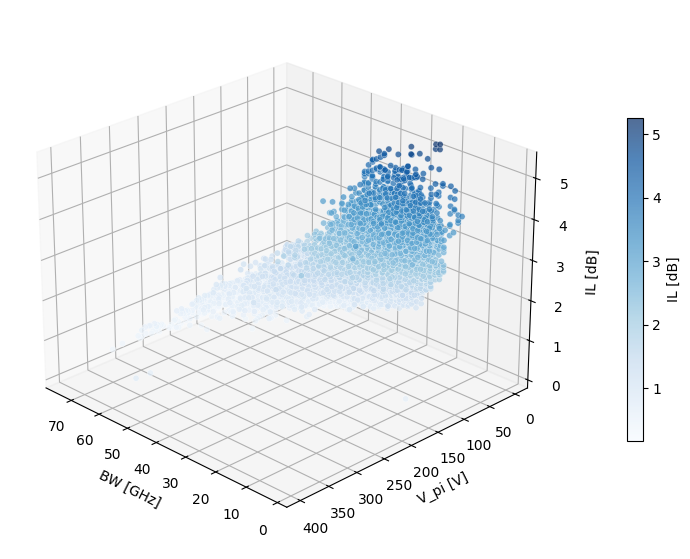

In [7]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter
sc = ax.scatter(x, y, c, c=c, cmap='Blues', s=20, alpha=0.7, edgecolors='w', linewidth=0.3)

# Axes labels
ax.set_xlabel('BW [GHz]')
ax.set_ylabel('V_pi [V]')
ax.set_zlabel('IL [dB]')

# Optional: colorbar to reinforce the color scale
cbar = plt.colorbar(sc, pad=0.1, shrink=0.6)
cbar.set_label('IL [dB]')

# Optional: view angle
ax.view_init(elev=25, azim=135)  # tweak as needed

plt.show()

## GPU Setup

In [ ]:
# JAX automatically uses GPU/TPU if available
print(f"JAX backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")

# JAX arrays are placed on the default device automatically
print(f"x_train device: {x_train_t.devices()}")

Using device: cuda


## Training Function
A self-contained training function that accepts all hyperparameters and returns the final train/test losses.

In [ ]:
def train_model(
    lambda_bw_mon,
    lambda_IL_mon,
    lambda_vpiL,
    lambda_smooth,
    # Fixed hyperparameters (change below if needed)
    D_i=8,
    D_o=3,
    dropout_rate=0.2,
    batch_size=128,
    learning_rate=1e-3,
    weight_decay=0.05,
    n_epoch=100,
    verbose=False,
    trial=None,  # Optuna trial for pruning
):
    """
    Build, train and evaluate a MLP-PINN model with the given hyperparameters.

    Returns
    -------
    dict with keys:
        'train_loss', 'test_loss',
        'train_history', 'test_history',
        'params', 'batch_stats', 'n_params'
    """
    global rng_key

    # --- Build model ---
    model = MLP5(input_dim=D_i, output_dim=D_o, dropout_rate=dropout_rate)

    # Initialize parameters and batch stats
    rng_key, init_key, dropout_key = random.split(rng_key, 3)
    variables = model.init(
        {'params': init_key, 'dropout': dropout_key},
        jnp.ones((1, D_i)),
        training=True,
    )
    params = variables['params']
    batch_stats = variables['batch_stats']

    n_params = sum(p.size for p in jax.tree.leaves(params))

    # Optimizer (AdamW)
    optimizer = optax.adamw(learning_rate=learning_rate, weight_decay=weight_decay)
    opt_state = optimizer.init(params)

    n_train = x_train_t.shape[0]
    train_hist = np.zeros(n_epoch)
    test_hist  = np.zeros(n_epoch)

    # --- JIT-compiled training step ---
    @jax.jit
    def train_step(params, batch_stats, opt_state, x_batch, y_batch,
                   dropout_rng, lam_bw, lam_il, lam_vpi, lam_sm):

        def loss_fn(params):
            variables = {'params': params, 'batch_stats': batch_stats}
            pred, updates = model.apply(
                variables, x_batch, training=True,
                rngs={'dropout': dropout_rng},
                mutable=['batch_stats'],
            )
            new_bs = updates['batch_stats']

            # Data loss (MSE)
            data_loss = jnp.mean((pred - y_batch) ** 2)

            # --- Physics losses via forward-mode AD (JVP) ---
            def pred_eval(x):
                return model.apply(
                    {'params': params, 'batch_stats': new_bs},
                    x, training=False,
                )

            e_L = jnp.zeros_like(x_batch).at[:, 7].set(1.0)
            _, dpred_dL = jax.jvp(pred_eval, (x_batch,), (e_L,))

            dBW_dL  = dpred_dL[:, 0]
            dIL_dL  = dpred_dL[:, 1]
            dVpi_dL = dpred_dL[:, 2]

            # 1) dBW/dL <= 0
            bw_mon_loss = jnp.mean(jax.nn.relu(dBW_dL) ** 2)

            # 2) dIL/dL >= 0
            il_mon_loss = jnp.mean(jax.nn.relu(-dIL_dL) ** 2)

            # 3) d(Vpi·L)/dL ≈ 0  (product rule: Vpi + L·dVpi/dL)
            dVpiL_dL = pred[:, 2] + x_batch[:, 7] * dVpi_dL
            vpiL_loss = jnp.mean(dVpiL_dL ** 2)

            # 4) Smoothness — d²BW/dL² via nested JVP
            def dbw_dL_fn(x):
                def bw_fn(xi):
                    return model.apply(
                        {'params': params, 'batch_stats': new_bs},
                        xi, training=False,
                    )[:, 0]
                e = jnp.zeros_like(x).at[:, 7].set(1.0)
                _, d = jax.jvp(bw_fn, (x,), (e,))
                return d

            _, d2BW_dL2 = jax.jvp(dbw_dL_fn, (x_batch,), (e_L,))
            smooth_loss = jnp.mean(d2BW_dL2 ** 2)

            physics_loss = (
                lam_bw * bw_mon_loss
                + lam_il * il_mon_loss
                + lam_vpi * vpiL_loss
                + lam_sm * smooth_loss
            )

            return data_loss + physics_loss, new_bs

        (loss, new_bs), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)

        return new_params, new_bs, new_opt_state, loss

    @jax.jit
    def eval_loss(params, batch_stats, x, y):
        pred = model.apply(
            {'params': params, 'batch_stats': batch_stats},
            x, training=False,
        )
        return jnp.mean((pred - y) ** 2)

    # --- Training loop ---
    for epoch in range(n_epoch):
        rng_key, shuffle_key = random.split(rng_key)
        perm = random.permutation(shuffle_key, n_train)

        for i in range(0, n_train, batch_size):
            idx = perm[i:i + batch_size]
            x_batch = x_train_t[idx]
            y_batch = y_train_t[idx]

            rng_key, step_key = random.split(rng_key)
            params, batch_stats, opt_state, _ = train_step(
                params, batch_stats, opt_state,
                x_batch, y_batch, step_key,
                lambda_bw_mon, lambda_IL_mon, lambda_vpiL, lambda_smooth,
            )

        # --- Evaluation ---
        train_loss = float(eval_loss(params, batch_stats, x_train_t, y_train_t))
        test_loss  = float(eval_loss(params, batch_stats, x_test_t, y_test_t))
        train_hist[epoch] = train_loss
        test_hist[epoch]  = test_loss

        if verbose and (epoch % 5 == 0 or epoch == n_epoch - 1):
            print(f"  Epoch {epoch:4d} | Train {train_loss:.6f} | Test {test_loss:.6f}")

        # Optuna pruning
        if trial is not None:
            trial.report(test_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    return {
        'train_loss':    train_hist[-1],
        'test_loss':     test_hist[-1],
        'train_history': train_hist,
        'test_history':  test_hist,
        'params':        params,
        'batch_stats':   batch_stats,
        'n_params':      n_params,
    }

## Hyperparameter Search Configuration

Define the search space for all tuned hyperparameters.

In [18]:
# ==============================
# Search Space Definition
# ==============================

# Number of Optuna trials
N_OPTUNA_TRIALS = 50

# Training epochs per trial (lower for faster search; retrain best with more)
SEARCH_EPOCHS = 100

# Final retraining epochs for the best config
FINAL_EPOCHS = 400

## Optuna Search
Uses TPE sampler and median pruner.

In [19]:
def objective(trial):
    # --- Sample hyperparameters ---
    lambda_bw_mon = trial.suggest_float("lambda_bw_mon", 0.0, 1.0)
    lambda_IL_mon = trial.suggest_float("lambda_IL_mon", 0.0, 1.0)
    lambda_vpiL   = trial.suggest_float("lambda_vpiL",   0.0, 1.0)
    lambda_smooth  = trial.suggest_float("lambda_smooth", 0.0, 1.0)

    result = train_model(
        lambda_bw_mon=lambda_bw_mon,
        lambda_IL_mon=lambda_IL_mon,
        lambda_vpiL=lambda_vpiL,
        lambda_smooth=lambda_smooth,
        n_epoch=SEARCH_EPOCHS,
        verbose=True,
        trial=trial,
    )
    return result['test_loss']

In [20]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=random_state),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=20),
)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

# --- Best trial summary ---
best = study.best_trial
print("\n" + "="*50)
print(f"Best test loss: {best.value:.6f}")
print("Best hyperparameters:")
for k, v in best.params.items():
    if k == "hidden_dims_idx":
        print(f"  hidden_dims = {HIDDEN_DIM_OPTIONS[v]}")
    else:
        print(f"  {k} = {v}")
print("="*50)

[I 2026-03-10 10:53:11,684] A new study created in memory with name: no-name-6bbef7dc-46b9-403c-a841-567a61a7fc1f
  0%|                                                                                                                                                                   | 0/50 [00:00<?, ?it/s]

  Epoch    0 | Train 0.216800 | Test 0.225510


  0%|                                                                                                                                                                   | 0/50 [00:17<?, ?it/s]


[W 2026-03-10 10:53:29,239] Trial 0 failed with parameters: {'lambda_bw_mon': 0.6964691855978616, 'lambda_IL_mon': 0.28613933495037946, 'lambda_vpiL': 0.2268514535642031, 'lambda_smooth': 0.5513147690828912} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/salastro/Documents/Research/MZM/code/venv/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_17434/922382064.py", line 8, in objective
    result = train_model(
        lambda_bw_mon=lambda_bw_mon,
    ...<5 lines>...
        trial=trial,
    )
  File "/tmp/ipykernel_17434/3117831414.py", line 51, in train_model
    for x_batch, y_batch in data_loader:
                            ^^^^^^^^^^^
  File "/home/salastro/Documents/Research/MZM/code/venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
  File "/home/salastro/Documents/Resear

KeyboardInterrupt: 

## Results Analysis & Visualization

In [ ]:
# ==============================
# Collect best hyperparameters
# ==============================
bp = study.best_trial.params
best_config = {
    'lambda_bw_mon': bp['lambda_bw_mon'],
    'lambda_IL_mon': bp['lambda_IL_mon'],
    'lambda_vpiL':   bp['lambda_vpiL'],
    'lambda_smooth': bp['lambda_smooth'],
}

In [21]:
# [I 2026-03-04 00:45:25,455] Trial 0 finished with value: 0.022303292527794838 and parameters: {'n_experts': 60, 'hidden_dims_idx': 5, 'lambda_bw_mon': 0.6848297385848633, 'lambda_IL_mon': 0.48093190148436094, 'lambda_vpiL': 0.3921175181941505, 'lambda_smooth': 0.3431780161508694}. Best is trial 0 with value: 0.022303292527794838.
best_config = {
    'lambda_bw_mon': 0.1,
    'lambda_IL_mon': 0.1,
    'lambda_vpiL':   0.05,
    'lambda_smooth': 0.01,
}


In [ ]:
# ==============================
# Optuna Visualizations
# ==============================
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
)

fig = plot_optimization_history(study)
plt.title("Optimization History")
plt.tight_layout()
plt.show()

fig = plot_param_importances(study)
plt.tight_layout()
plt.show()

fig = plot_parallel_coordinate(study)
plt.title("Parallel Coordinate Plot")
plt.tight_layout()
plt.show()

fig = plot_slice(study)
# plt.tight_layout()
plt.show()

## Retrain Best Model (Full Epochs)
Retrain the best configuration with more epochs and verbose logging.

In [23]:
print(f"Retraining best config for {FINAL_EPOCHS} epochs ...\n")

final_result = train_model(
    lambda_bw_mon=best_config['lambda_bw_mon'],
    lambda_IL_mon=best_config['lambda_IL_mon'],
    lambda_vpiL=best_config['lambda_vpiL'],
    lambda_smooth=best_config['lambda_smooth'],
    n_epoch=FINAL_EPOCHS,
    verbose=True,
)

print(f"\nFinal Train Loss: {final_result['train_loss']:.6f}")
print(f"Final Test  Loss: {final_result['test_loss']:.6f}")
print(f"Model parameters: {final_result['n_params']}")

Retraining best config for 100 epochs ...

  Epoch    0 | Train 0.123672 | Test 0.117121
  Epoch    5 | Train 0.058353 | Test 0.052219
  Epoch   10 | Train 0.047767 | Test 0.040638
  Epoch   15 | Train 0.042317 | Test 0.040997
  Epoch   20 | Train 0.042650 | Test 0.040168
  Epoch   25 | Train 0.032180 | Test 0.029590
  Epoch   30 | Train 0.030206 | Test 0.026437
  Epoch   35 | Train 0.028721 | Test 0.026721
  Epoch   40 | Train 0.031349 | Test 0.027541
  Epoch   45 | Train 0.030079 | Test 0.028646
  Epoch   50 | Train 0.041576 | Test 0.039080
  Epoch   55 | Train 0.029829 | Test 0.029878
  Epoch   60 | Train 0.026144 | Test 0.027161
  Epoch   65 | Train 0.023315 | Test 0.022131
  Epoch   70 | Train 0.023294 | Test 0.020837
  Epoch   75 | Train 0.028006 | Test 0.026030
  Epoch   80 | Train 0.021412 | Test 0.019874
  Epoch   85 | Train 0.032519 | Test 0.031292
  Epoch   90 | Train 0.019436 | Test 0.017926
  Epoch   95 | Train 0.020454 | Test 0.019676
  Epoch   99 | Train 0.021005 | Test 

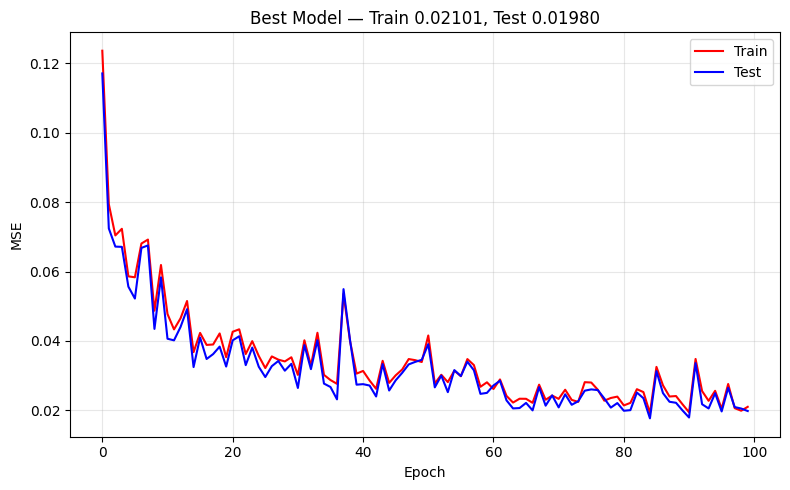

In [24]:
# ==============================
# Training Curves for Best Model
# ==============================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(final_result['train_history'], 'r-', label='Train')
ax.plot(final_result['test_history'],  'b-', label='Test')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title(
    f"Best Model — Train {final_result['train_loss']:.5f}, "
    f"Test {final_result['test_loss']:.5f}"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Per-Output Error Analysis

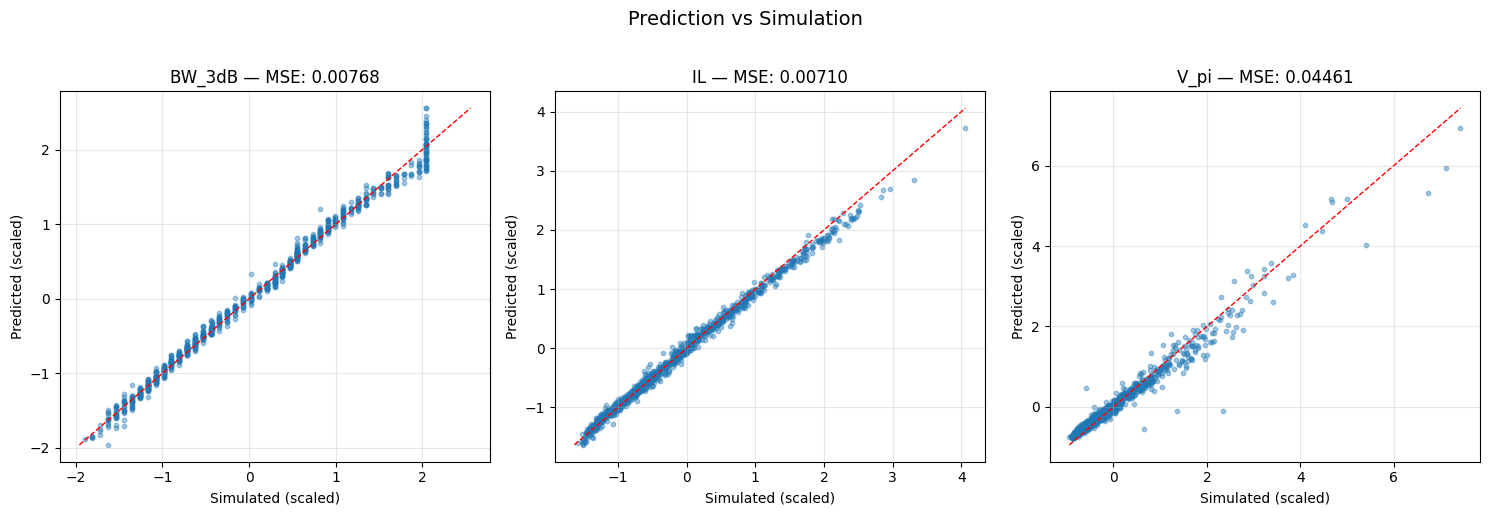

In [ ]:
# ==============================
# Load best model and evaluate per-output
# ==============================
best_model = MLP5()
best_variables = {
    'params': final_result['params'],
    'batch_stats': final_result['batch_stats'],
}

pred_test = np.array(best_model.apply(best_variables, x_test_t, training=False))
y_test_np = np.array(y_test_t)

target_names = ['BW_3dB', 'IL', 'V_pi']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (name, ax) in enumerate(zip(target_names, axes)):
    ax.scatter(y_test_np[:, i], pred_test[:, i], alpha=0.4, s=10)
    lims = [
        min(y_test_np[:, i].min(), pred_test[:, i].min()),
        max(y_test_np[:, i].max(), pred_test[:, i].max()),
    ]
    ax.plot(lims, lims, 'r--', lw=1)
    mse_i = np.mean((y_test_np[:, i] - pred_test[:, i])**2)
    ax.set_title(f"{name} — MSE: {mse_i:.5f}")
    ax.set_xlabel('Simulated (scaled)')
    ax.set_ylabel('Predicted (scaled)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Prediction vs Simulation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Save Best Configuration

In [ ]:
# ==============================
# Save results
# ==============================
save_dict = {
    'best_config': {k: (v if not isinstance(v, list) else v)
                    for k, v in best_config.items()},
    'final_train_loss': float(final_result['train_loss']),
    'final_test_loss':  float(final_result['test_loss']),
    'n_params': final_result['n_params'],
}

with open('best_hyperparams.json', 'w') as f:
    json.dump(save_dict, f, indent=2)
print("Saved to best_hyperparams.json")

# Save model weights (convert JAX arrays to numpy for serialization)
model_state = jax.tree.map(
    lambda x: np.array(x),
    {'params': final_result['params'], 'batch_stats': final_result['batch_stats']},
)
with open('best_model.pkl', 'wb') as f:
    pickle.dump(model_state, f)
print("Saved model weights to best_model.pkl")

print("\nBest configuration summary:")
print(json.dumps(save_dict, indent=2))

Saved to best_hyperparams.json
Saved model weights to best_model.pt

Best configuration summary:
{
  "best_config": {
    "n_experts": 60,
    "hidden_dims": [
      64,
      128,
      64
    ],
    "lambda_bw_mon": 0.6848297385848633,
    "lambda_IL_mon": 0.48093190148436094,
    "lambda_vpiL": 0.3921175181941505,
    "lambda_smooth": 0.3431780161508694
  },
  "final_train_loss": 0.006827645469456911,
  "final_test_loss": 0.019174175336956978,
  "n_params": 1072152
}
